In [31]:
from matplotlib.pyplot import cm
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
from scipy import constants as cst
import sys, os, git
import warnings
warnings.filterwarnings("ignore")

In [32]:
current_path = os.getcwd()
git_repo = git.Repo(current_path, search_parent_directories=True)
git_path = git_repo.git.rev_parse("--show-toplevel")
path_figures = current_path[len(git_path):] + '/'
path_in_folder = current_path[len(git_path)+1:]

In [33]:
sys.path.append(git_path + "/.submodules/pyplot-perso")
from plttools import PltTools

In [34]:
cmap_cool = cm.cool
cmap_dark_blue_to_cyan = LinearSegmentedColormap.from_list('dark_blue_to_cyan', ['#1D11CB', cmap_cool(0.0)])
cmap_viridis = cm.viridis      # excellent general-purpose
cmap_cividis = cm.cividis      # best for accessibility (colorblind-safe)
cmap_turbo   = cm.turbo        # very high contrast, vivid range
cmap_plasma  = cm.plasma       # strong contrast, warm highlights
cmap_inferno = cm.inferno      # dark-to-bright, great on dark BG
cmap_magma   = cm.magma        # smoother dark-background readability

  Pixels: width = 685.5 x height = 649.8
  Aspect ratio: 1.0549
  Pixels: width = 685.5 x height = 649.8
  Aspect ratio: 1.0549


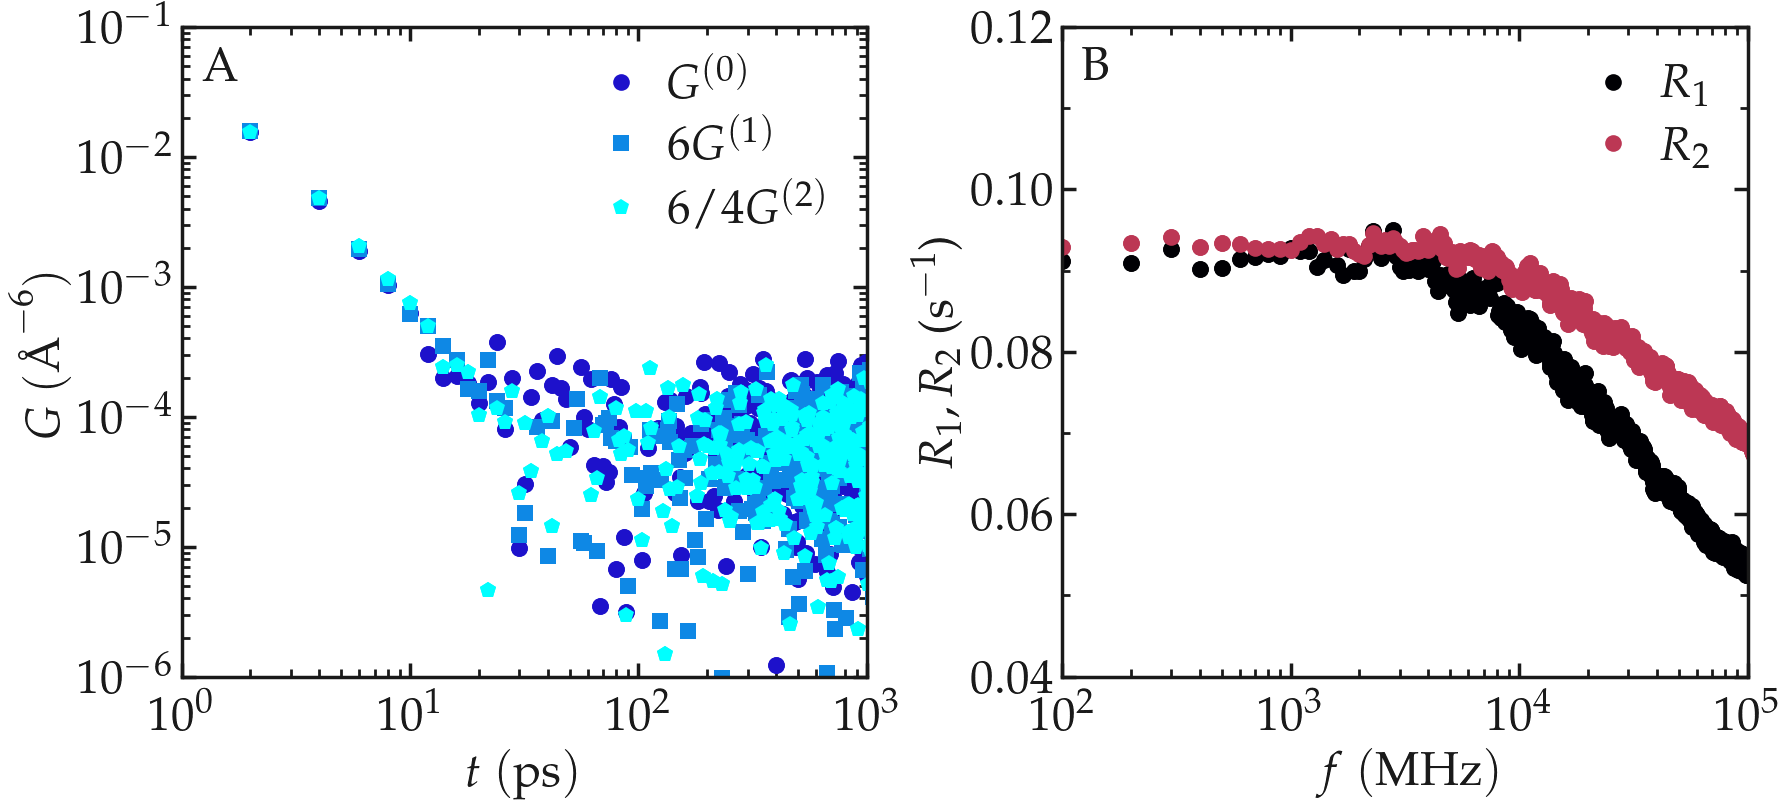

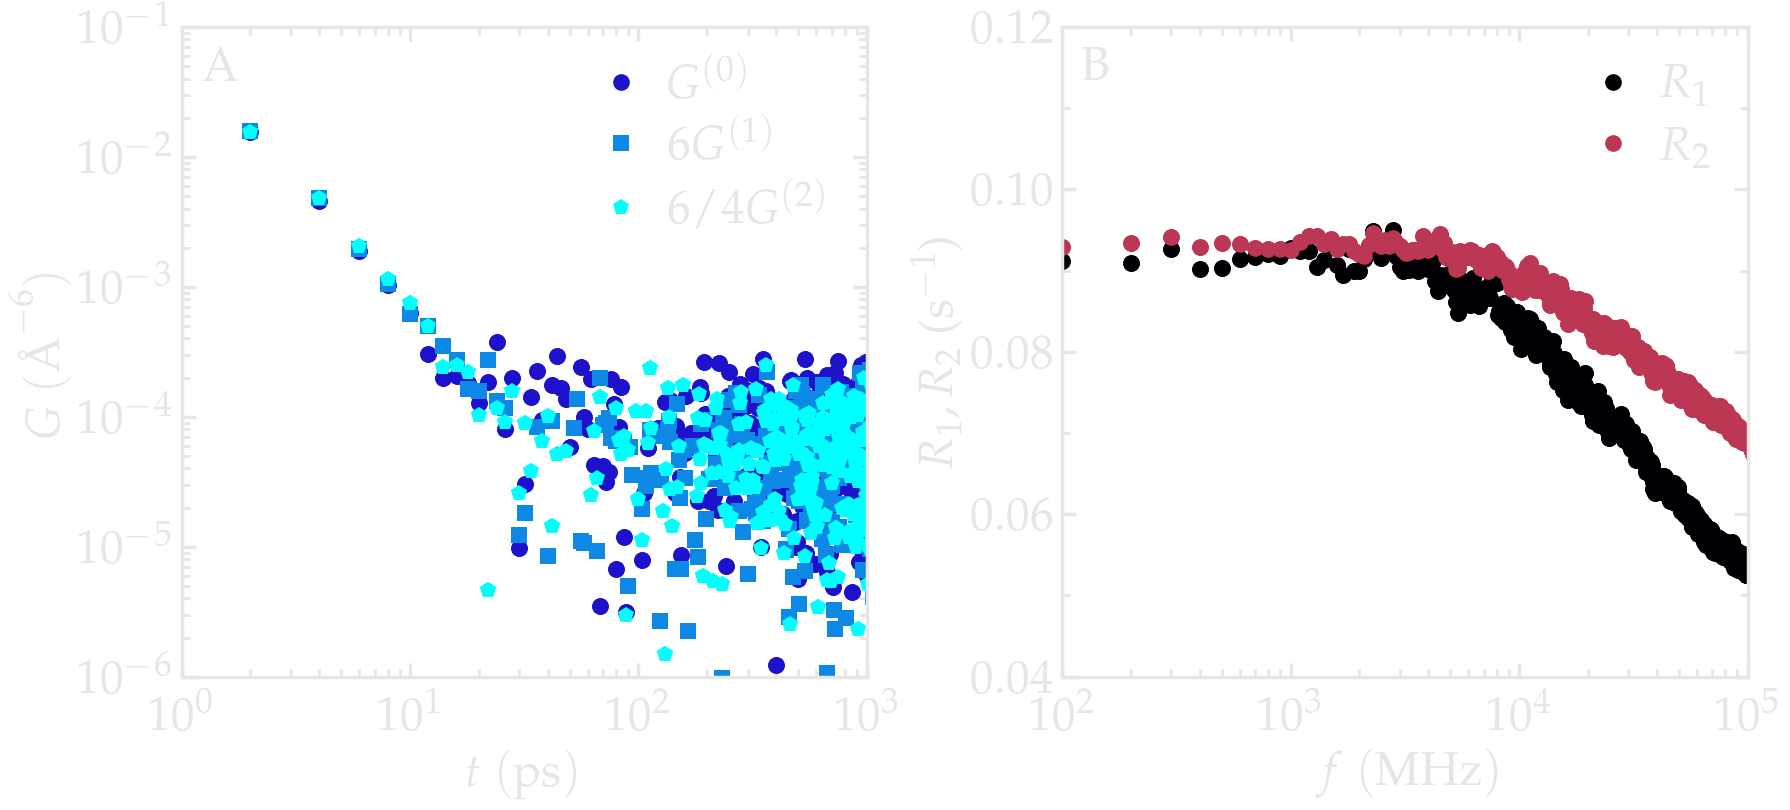

In [38]:
data_path = git_path + "/.submodules/dataset-pure-water/analysis/"

n = 5

for dark_mode in [False, True]:

    myplt = PltTools()
    myplt.prepare_figure(fig_size = (18,8.2), dark_mode = dark_mode,
                         transparency = True, use_serif=True, n_colone = 2)

    # Panel 1
    myplt.add_panel()

    all_gij_0 = []
    all_gij_1 = []
    all_gij_2 = []

    for repetition in range(20):

        type = "full"
        result_file =data_path +  f"nmr_{type}/result{n}-{repetition}.npy"
        data = np.load(result_file, allow_pickle=True).item()

        t = data["t"]
        gij_0 = data["C"][0]
        gij_1 = data["C"][1]
        gij_2 = data["C"][2]
        all_gij_0.append(gij_0)
        all_gij_1.append(gij_1)
        all_gij_2.append(gij_2)

    mean_gij_0 = np.mean(all_gij_0, axis = 0)
    mean_gij_1 = np.mean(all_gij_1, axis = 0)
    mean_gij_2 = np.mean(all_gij_2, axis = 0)
    std_gij_0 = np.std(all_gij_0, axis = 0)
    std_gij_1 = np.std(all_gij_1, axis = 0)
    std_gij_2 = np.std(all_gij_2, axis = 0)

    filename = "proportionality-G"
    colors = cmap_dark_blue_to_cyan(np.linspace(0, 1, 3))

    myplt.add_plot(x = t, y = mean_gij_0, type = "loglog", linewidth_data = 3,
                marker = "o", data_color = colors[0][:3], markersize = 12,
                data_label = r'$G^{(0)}$')
    
    myplt.add_plot(x = t, y = 6 * mean_gij_1, type = "loglog", linewidth_data = 3,
                marker = "s", data_color = colors[1][:3], markersize = 12,
                data_label = r'$6 G^{(1)}$')
    
    myplt.add_plot(x = t, y = 6 * mean_gij_2 / 4, type = "loglog", linewidth_data = 3,
                marker = "p", data_color = colors[2][:3], markersize = 12,
                data_label = r'$6 / 4 G^{(2)}$')
    
    myplt.complete_panel(ylabel = r'$G ~(\mathrm{\AA{}}^{-6})$', xlabel = r'$t~(\mathrm{ps})$',
                         xpad = 15, legend=True, handlelength_legend=1)
    myplt.set_boundaries(x_boundaries=(1, 1000), y_boundaries=(1e-6, 0.1))

    # Panel 2
    myplt.add_panel()
    colors = cmap_inferno(np.linspace(0, 1, 3))

    for repetition in range(20):

        type = "inter"
        result_file =data_path +  f"nmr_{type}/result{n}-{repetition}.npy"
        data = np.load(result_file, allow_pickle=True).item()

        f = data["f"]
        R1 = data["R1"]
        R2 = data["R2"]

    myplt.add_plot(x = f, y = R1, type = "semilogx", linewidth_data = 3,
                marker = "o", data_color = colors[0][:3], markersize = 12,
                data_label = r'$R_1$')
    myplt.add_plot(x = f, y = R2, type = "semilogx", linewidth_data = 3,
        marker = "o", data_color = colors[-2][:3], markersize = 12,
        data_label = r'$R_2$')
    
    myplt.complete_panel(ylabel = r'$R_1, R_2$ (s$^{-1}$)', xlabel = r'$f~(\mathrm{MHz})$',
                         xpad = 15, legend=True, handlelength_legend=1)
    myplt.set_boundaries(x_boundaries=(100, 1e5), y_boundaries=(0.04, 0.11), y_ticks = [0.04, 0.06, 0.08, 0.1, 0.12])

    myplt.add_subplotlabels(type_label_panel = "A")
    myplt.save_figure(filename = filename, saving_path = git_path+path_figures)